AB test for oil well production
compare model A and B

Write a Python code that:

Uses a fixed random seed (e.g., 42) so that the results are reproducible every time the code runs.

Generates two simple models for oil well IP30 (initial production rate at 30 days) as a function of rock permeability:

Model A = old standard model

Model B = new proposed model

Uses fictitious permeability values for several wells in a region (multiple records).

Tests whether Model B works significantly better than Model A, and whether the improvement is not just a coincidence (i.e., reject the null hypothesis 
H
0
H 
0
​
  at 
p
<
0.05
p<0.05).

Produces plots that include:

Histograms of both models (density normalized)

PDF (Probability Density Function) curves for both models on the same plot, with vertical lines showing the mean of each model for visual comparison of mean and variance

Scatter plot of IP30 vs permeability

Box plot to compare variance visually

Distribution of paired differences with its PDF

Calculates and prints:

Mean, variance, and standard deviation for each model

t-values (both paired and independent t-tests)

p-values

A clear decision (reject or fail to reject 
H
0
H 
0
​
 ) at 
α
=
0.05
α=0.05

Includes a summary table with all key statistics and the random seed used.

Using random seed: 42


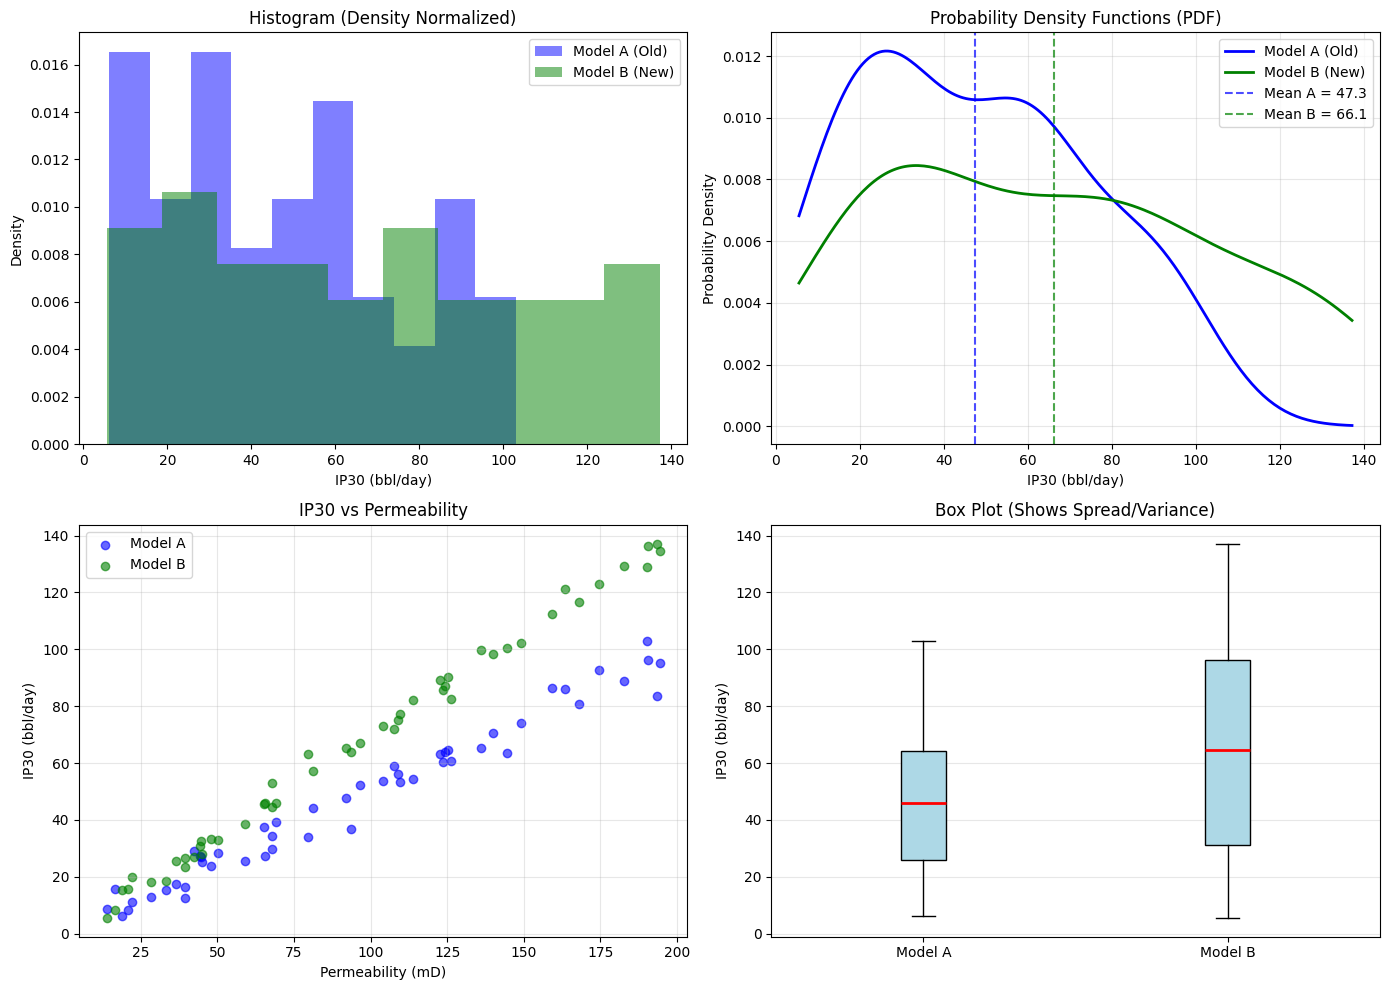

DESCRIPTIVE STATISTICS
Model A (Old) - Mean: 47.35 bbl/day, Variance: 756.55, Std: 27.51
Model B (New) - Mean: 66.14 bbl/day, Variance: 1532.95, Std: 39.15
Difference (B - A): 18.79 bbl/day

PAIRED T-TEST RESULTS
t-statistic: 10.0223
p-value: 0.000000

Significance level (alpha): 0.05

 REJECT the Null Hypothesis (H0)
   Conclusion: Model B works SIGNIFICANTLY better than Model A.
   The improvement is NOT a coincidence.

INDEPENDENT T-TEST (for reference)
t-statistic: 2.7764
p-value: 0.006585


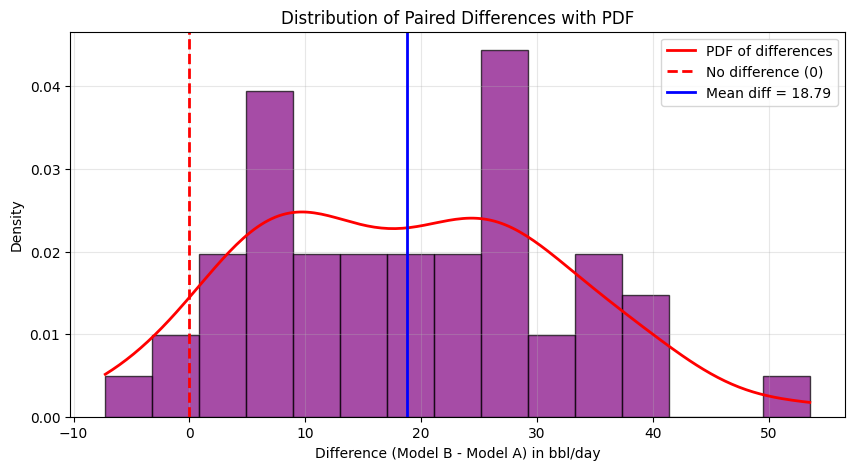


SUMMARY TABLE
Metric                         Model A         Model B        
----------------------------------------------------------------------
Mean IP30 (bbl/day)            47.35           66.14          
Variance                       756.55          1532.95        
Standard Deviation             27.51           39.15          
Sample size                    50              50             
t-statistic (paired)           10.0223        
p-value                        0.000000       
Reject H0 at alpha=0.05?       Yes            
Random seed used               42             

NOTE: Run this code again with the SAME random seed to get
      EXACTLY the same results. Change seed to 43
      to get different but reproducible results.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde

# ============================================
# SET RANDOM SEED FOR REPRODUCIBILITY
# ============================================
# You can change this number to get different but reproducible results
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f"Using random seed: {RANDOM_SEED}")

# ============================================
# 1. Generate fictitious permeability data for 50 wells
# ============================================
n_wells = 50
permeability = np.random.uniform(10, 200, n_wells)  # in millidarcies

# ============================================
# 2. Define the two models: IP30 = f(permeability)
# ============================================

# Model A: Old standard model (linear with some noise)
# IP30 = 0.5 * permeability + random noise
def model_A(perm):
    return 0.5 * perm + np.random.normal(0, 5, size=len(perm))

# Model B: New proposed model (better: 0.7 * permeability + less noise)
# This model is deliberately better (higher IP30 for same permeability)
def model_B(perm):
    return 0.7 * perm + np.random.normal(0, 3, size=len(perm))

# ============================================
# 3. Calculate IP30 for both models
# ============================================
IP30_A = model_A(permeability)
IP30_B = model_B(permeability)

# ============================================
# 4. Plot distributions (Histogram + KDE for PDF)
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 4a. Histogram plot
axes[0, 0].hist(IP30_A, bins=10, alpha=0.5, label='Model A (Old)', color='blue', density=True)
axes[0, 0].hist(IP30_B, bins=10, alpha=0.5, label='Model B (New)', color='green', density=True)
axes[0, 0].set_xlabel('IP30 (bbl/day)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Histogram (Density Normalized)')
axes[0, 0].legend()

# 4b. PDF using Kernel Density Estimation (Smooth curves)
# Calculate KDE for Model A
kde_A = gaussian_kde(IP30_A)
x_range = np.linspace(min(IP30_A.min(), IP30_B.min()), 
                       max(IP30_A.max(), IP30_B.max()), 200)
pdf_A = kde_A(x_range)

# Calculate KDE for Model B
kde_B = gaussian_kde(IP30_B)
pdf_B = kde_B(x_range)

# Plot PDFs
axes[0, 1].plot(x_range, pdf_A, 'b-', linewidth=2, label='Model A (Old)')
axes[0, 1].plot(x_range, pdf_B, 'g-', linewidth=2, label='Model B (New)')
# Add vertical lines for means
axes[0, 1].axvline(np.mean(IP30_A), color='blue', linestyle='--', alpha=0.7, 
                   label=f'Mean A = {np.mean(IP30_A):.1f}')
axes[0, 1].axvline(np.mean(IP30_B), color='green', linestyle='--', alpha=0.7, 
                   label=f'Mean B = {np.mean(IP30_B):.1f}')
axes[0, 1].set_xlabel('IP30 (bbl/day)')
axes[0, 1].set_ylabel('Probability Density')
axes[0, 1].set_title('Probability Density Functions (PDF)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 4c. Scatter plot
axes[1, 0].scatter(permeability, IP30_A, alpha=0.6, label='Model A', color='blue')
axes[1, 0].scatter(permeability, IP30_B, alpha=0.6, label='Model B', color='green')
axes[1, 0].set_xlabel('Permeability (mD)')
axes[1, 0].set_ylabel('IP30 (bbl/day)')
axes[1, 0].set_title('IP30 vs Permeability')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4d. Box plot for variance comparison
bp = axes[1, 1].boxplot([IP30_A, IP30_B], labels=['Model A', 'Model B'], 
                         patch_artist=True,
                         boxprops=dict(facecolor='lightblue'),
                         medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_ylabel('IP30 (bbl/day)')
axes[1, 1].set_title('Box Plot (Shows Spread/Variance)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================
# 5. Calculate mean and variance for both models
# ============================================
mean_A = np.mean(IP30_A)
var_A = np.var(IP30_A, ddof=1)  # sample variance
std_A = np.std(IP30_A, ddof=1)

mean_B = np.mean(IP30_B)
var_B = np.var(IP30_B, ddof=1)  # sample variance
std_B = np.std(IP30_B, ddof=1)

print("=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)
print(f"Model A (Old) - Mean: {mean_A:.2f} bbl/day, Variance: {var_A:.2f}, Std: {std_A:.2f}")
print(f"Model B (New) - Mean: {mean_B:.2f} bbl/day, Variance: {var_B:.2f}, Std: {std_B:.2f}")
print(f"Difference (B - A): {mean_B - mean_A:.2f} bbl/day")

# ============================================
# 6. Paired t-test (since same wells, same permeability values)
# ============================================
differences = IP30_B - IP30_A
t_stat, p_value = stats.ttest_rel(IP30_B, IP30_A)

print("\n" + "=" * 70)
print("PAIRED T-TEST RESULTS")
print("=" * 70)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

# ============================================
# 7. Decision against H0 at alpha = 0.05
# ============================================
alpha = 0.05
print(f"\nSignificance level (alpha): {alpha}")

if p_value < alpha:
    print("\n REJECT the Null Hypothesis (H0)")
    print("   Conclusion: Model B works SIGNIFICANTLY better than Model A.")
    print("   The improvement is NOT a coincidence.")
else:
    print("\n❌ FAIL to reject the Null Hypothesis (H0)")
    print("   Conclusion: No significant difference between models.")
    print("   The apparent improvement could be due to chance.")

# ============================================
# 8. Additional: Independent t-test (just for comparison)
# ============================================
t_stat_ind, p_value_ind = stats.ttest_ind(IP30_B, IP30_A)
print("\n" + "=" * 70)
print("INDEPENDENT T-TEST (for reference)")
print("=" * 70)
print(f"t-statistic: {t_stat_ind:.4f}")
print(f"p-value: {p_value_ind:.6f}")

# ============================================
# 9. Visualize the difference distribution
# ============================================
plt.figure(figsize=(10, 5))
plt.hist(differences, bins=15, color='purple', alpha=0.7, edgecolor='black', density=True)

# Add KDE for differences
kde_diff = gaussian_kde(differences)
x_diff = np.linspace(differences.min(), differences.max(), 200)
pdf_diff = kde_diff(x_diff)
plt.plot(x_diff, pdf_diff, 'r-', linewidth=2, label='PDF of differences')

plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No difference (0)')
plt.axvline(x=np.mean(differences), color='blue', linestyle='-', linewidth=2, 
            label=f'Mean diff = {np.mean(differences):.2f}')
plt.xlabel('Difference (Model B - Model A) in bbl/day')
plt.ylabel('Density')
plt.title('Distribution of Paired Differences with PDF')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# 10. Summary table
# ============================================
print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
print(f"{'Metric':<30} {'Model A':<15} {'Model B':<15}")
print("-" * 70)
print(f"{'Mean IP30 (bbl/day)':<30} {mean_A:<15.2f} {mean_B:<15.2f}")
print(f"{'Variance':<30} {var_A:<15.2f} {var_B:<15.2f}")
print(f"{'Standard Deviation':<30} {std_A:<15.2f} {std_B:<15.2f}")
print(f"{'Sample size':<30} {n_wells:<15} {n_wells:<15}")
print(f"{'t-statistic (paired)':<30} {t_stat:<15.4f}")
print(f"{'p-value':<30} {p_value:<15.6f}")
print(f"{'Reject H0 at alpha=0.05?':<30} {'Yes' if p_value < alpha else 'No':<15}")
print(f"{'Random seed used':<30} {RANDOM_SEED:<15}")

print("\n" + "=" * 70)
print("NOTE: Run this code again with the SAME random seed to get")
print(f"      EXACTLY the same results. Change seed to {RANDOM_SEED + 1}")
print("      to get different but reproducible results.")
print("=" * 70)